In [1]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_single_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Egypt", n=3)

Set up: Models, data, etc.

In [4]:
sampler = "ADVI"

cyto_color = colors[0]
lyso_color = colors[1]
mito_color = colors[2]

model = "MM_single"
model_info_file = '../models/MM_single.json'

data_dir = '../../../results/param_est/'
save_dir_base = '../../../results/param_est/stimulus_strength/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength

# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')
idata_lyso = az.from_netcdf(data_dir + model + '_lyso_mcmc_samples_' + sampler + '.nc')
idata_mito = az.from_netcdf(data_dir + model + '_mito_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

rhs = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
rhs = diffrax.ODETerm(rhs.time_dep_kGly)

Explore the time-dependent input funcs

Text(0.5, 0, 'Time')

/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


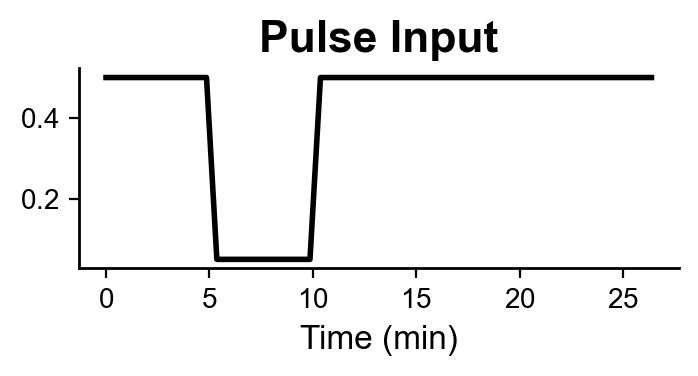

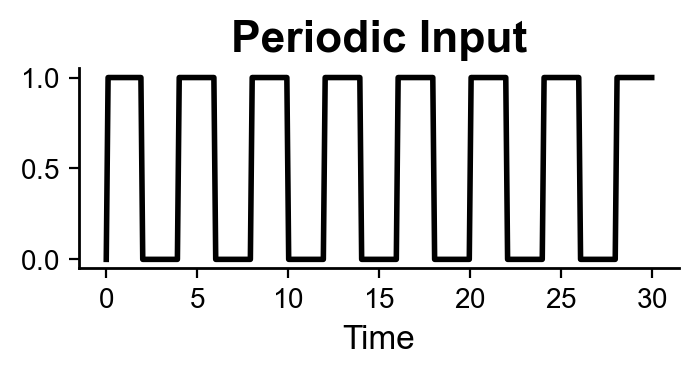

In [5]:
pulse = lambda t: pulse_input(t, 5*60, 10*60, amplitude=-0.45, shift=0.5)

# pulse
fig, ax = get_sized_fig_ax(3, 1)
ax.plot(times/60, pulse(times), color='k', lw=2, label='Stimulus Pulse')
ax.set_title('Pulse Input')
ax.set_xlabel('Time (min)')

# periodic
periodic = lambda t: square_input(t, frequency=0.25)
times_periodic = np.linspace(0, 30, 300)
fig, ax = get_sized_fig_ax(3, 1)
ax.plot(times_periodic, periodic(times_periodic), color='k', lw=2, label='Periodic Input')
ax.set_title('Periodic Input')
ax.set_xlabel('Time')

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [6]:
def solve_traj_timeDepKGly(rhs, rhs_stress, y0, params, times, rtol=1e-6, atol=1e-6, 
               evnt_rtol = 1e-12, evnt_atol = 1e-12, tmax_init = 1e3, 
               pcoeff=0, icoeff=1, dcoeff=0, solver = dfrx.Kvaerno5(), dt0=1e-10):
    """ simulates a model over the specified time interval and returns the 
    calculated values.
    Returns an array of shape (n_species, 1) 
    TODO add way to specify autodiff method
    """
    stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
    cond_fn=dfrx.steady_state_event(rtol=evnt_rtol, atol=evnt_atol)
    event = dfrx.Event(cond_fn=cond_fn)
    t0 = 0.0
    t1 = times[-1]
    saveat=dfrx.SaveAt(ts=times)
    max_steps=int(3e7)

    # first solve the basal model to SS
    sol = dfrx.diffeqsolve(
        rhs, solver, 
        t0, tmax_init, dt0, y0, 
        args=params,
        stepsize_controller=stepsize_controller,
        event=event,
        max_steps=max_steps, throw=True)
    
    # then use that solution as the initial condition for the stressed setting
    sol_stressed = dfrx.diffeqsolve(
        rhs_stress, solver, 
        t0, t1, dt0, 
        sol.ys, # use basal SS at IC
        args=params, saveat=saveat,
        stepsize_controller=stepsize_controller,
        max_steps=max_steps, throw=True)
    
    return jnp.squeeze(jnp.array(sol_stressed.ys)), jnp.squeeze(jnp.array(sol.ys))

def run_model_sims(k_gly_func, idata, nsamples=4):
    
    # get params from the idata
    params = get_param_subsample(param_names, idata, nsamples)

    # run the stress sims
    tmp = []
    for j in range(params.shape[0]):

        param = list(params[j, :])
        param.append(k_gly_func)

        stress_sol, _ = solve_traj_timeDepKGly(rhs, rhs, y0, param, times, rtol=1e-6, atol=1e-6, 
            evnt_rtol = 1e-12, evnt_atol = 1e-12, tmax_init = 1e3, 
            pcoeff=0.3, icoeff=0.4, dcoeff=0.0,)
            
        AMPKAR_stressed = stress_sol[jnp.array(ampkar_idxs), :].sum(axis=0)
        pAMPKAR_stressed = stress_sol[jnp.array(pampkar_idxs), :].sum(axis=0)
        tmp.append(pAMPKAR_stressed/AMPKAR_stressed)
    
    return np.array(tmp)

##### Run a couple of examples:

In [7]:
# pulse input
# need to ensure that time bounds are set in sec.
pulse = lambda t: pulse_input(t, 5*60, 10*60, amplitude=-0.45, shift=0.5) # drop in 0.25 of kGly for 5 mins

pulsed_response_cyto = run_model_sims(pulse, idata_cyto, nsamples=8)
pulsed_response_lyso = run_model_sims(pulse, idata_lyso, nsamples=8)
pulsed_response_mito = run_model_sims(pulse, idata_mito, nsamples=8)

Text(0, 0.5, 'fraction active\nsensor')

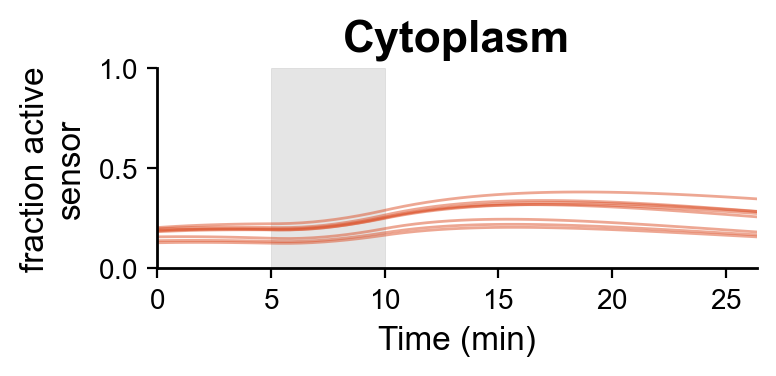

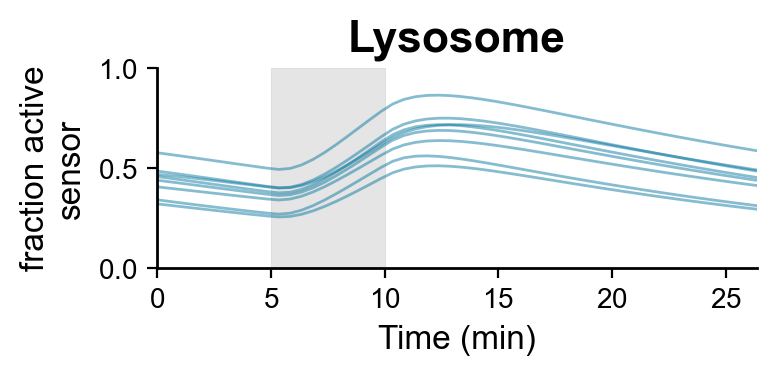

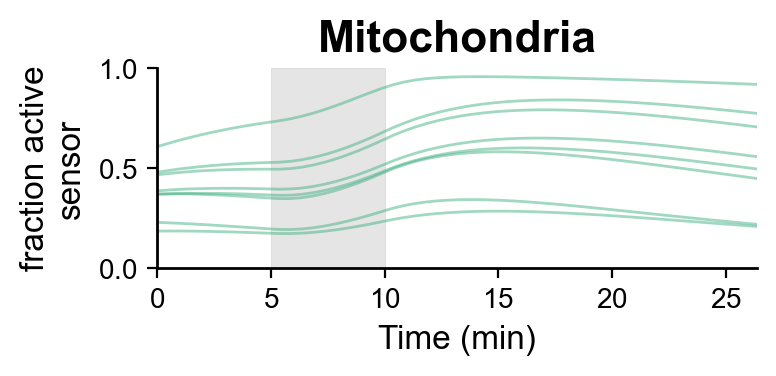

In [12]:
fig, ax = get_sized_fig_ax(3, 1)
ax.axvspan(5, 10, color='gray', alpha=0.2)
for i in range(pulsed_response_cyto.shape[0]):
    ax.plot(times/60, pulsed_response_cyto[i], color=cyto_color, lw=1, alpha=0.5)
ax.set_title('Cytoplasm')
ax.set_xlabel('Time (min)')
ax.set_xlim(0, times[-1]/60)  # Set x-axis limit to match the time of the pulse
ax.set_ylim(0, 1.0)
ax.set_ylabel('fraction active\nsensor')

fig, ax = get_sized_fig_ax(3, 1)
ax.axvspan(5, 10, color='gray', alpha=0.2)
for i in range(pulsed_response_lyso.shape[0]):
    ax.plot(times/60, pulsed_response_lyso[i], color=lyso_color, lw=1, alpha=0.5)
ax.set_title('Lysosome')
ax.set_xlabel('Time (min)')
ax.set_xlim(0, times[-1]/60)  # Set x-axis limit to match the time of the pulse
ax.set_ylim(0, 1.0)
ax.set_ylabel('fraction active\nsensor')

fig, ax = get_sized_fig_ax(3, 1)
ax.axvspan(5, 10, color='gray', alpha=0.2)
for i in range(pulsed_response_mito.shape[0]):
    ax.plot(times/60, pulsed_response_mito[i], color=mito_color, lw=1, alpha=0.5)
ax.set_title('Mitochondria')
ax.set_xlabel('Time (min)')
ax.set_xlim(0, times[-1]/60)  # Set x-axis limit to match the time of the pulse
ax.set_ylim(0, 1.0)
ax.set_ylabel('fraction active\nsensor')